In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import numpy as np
import fiona

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# states whos districting map changes 118-119: Alabama, Georgia, Louisiana, New York, and North Carolina

In [3]:
# congressional district boundaries CONG118 data set: https://redistrictingdatahub.org/dataset/118th-congressional-districts-nov-2022-election-active-jan-2023-jan-2025/
dists_map_8 = gpd.read_file("data/CONG118/national_cong118_carto_boundary.shp", engine="fiona")

# congressional district boundaries CONG119 data set: https://redistrictingdatahub.org/dataset/119th-congressional-districts-and-block-assignment-file-nov-2024-election-active-jan-2025-jan-2027/
dists_map = gpd.read_file("data/CONG119/national_cong119_carto_boundary.shp", engine="fiona")

# congressional district demographic information data set: https://redistrictingdatahub.org/dataset/119th-congress-district-level-data-demographic-economic-language-and-partisan/
dists_info = gpd.read_file("data/CONG119/national_cong119_district_data.csv", engine="fiona")

In [4]:
# shorten column names for demographic info
demo_dict = {
    'CONG119': 'CONG119',
    'STATE': 'STATE',
    'DISTRICT': 'DISTRICT', 
    'TOTPOP20': 'TOT_POP', 
    'NH White': 'WHITE',
    'NH Black plus NH Black and White': 'BLACK', 
    'NH Asian plus NH Asian and White': 'ASIAN',
    'NH American Indian plus NH American Indian and White': 'AMERIN',
    'NH Pacific Islander plus NH Pacific Islander and White': 'PACIS',
    'NH Some Other Race plus NH Some Other Race and White': 'OTHER',
    'NH Other multiple-race': 'MULTI', 
    'Hispanic': 'HISPANIC', 
    'TOT_HOUS22_est': 'TOT_HOUSE',
    'LESS_10K22_est': 'LESS_10K', 
    '10K_15K22_est': '10K_15K', 
    '15K_20K22_est': '15K_20K', 
    '20K_25K22_est': '20K_25K',
    '25K_30K22_est': '25K_30K',
    '30K_35K22_est': '30K_35K', 
    '35K_40K22_est': '35K_40K', 
    '40K_45K22_est': '40K_45K',
    '45K_50K22_est': '45K_50K', 
    '50K_60K22_est': '50K_60K', 
    '60K_75K22_est': '60K_75K', 
    '75K_100K22_est': '75K_100K',
    '100_125K22_est': '100K_125K', 
    '125_150K22_est': '125K_150K', 
    '150_200K22_est': '150K_200K', 
    '200K_MOR22_est': 'OVER_200K',
    'Median_HH_Income_Est': 'MED_HH_INC', 
    'BACH_PLUS_pct': 'BACH', 
    'FOREIGN_BORN_pct': 'FOREIGN',
    'ENG_LW_pct': 'ENG_LW', 
    'Total_20_Pres_Votes_Est': 'TOT_VOTES', 
    'G20PREDBID_pct': 'BIDEN',
    'G20PRELJOR_pct': 'JORGENSEN', 
    'G20PRERTRU_pct': 'TRUMP'
}

# rename columns and drop repeated columns
dists_info = dists_info.rename(columns = demo_dict)
dists_info["BIDEN"] = pd.to_numeric(dists_info["BIDEN"])
dists_demo = dists_info.drop(columns = ["STATE", "DISTRICT"])

# make data set with shp data and demographic data
dists = dists_map.merge(dists_demo, on = "CONG119", how = "left")

# divide district data for each state into separate dfs
states = [
    "AK", "AL", "AR", "AZ", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "IA",
    "ID", "IL", "IN", "KS", "KY", "LA", "MA", "MD", "ME", "MI", "MN", "MO",
    "MS", "MT", "NC", "ND", "NE", "NH", "NJ", "NM", "NV", "NY", "OH", "OK",
    "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VA", "VT", "WA", "WI",
    "WV", "WY"
]
for state in states:
    globals()[state] = dists[dists["STATE"] == state]


# do the same for cong118
dists_demo_8 = dists_demo.copy()
dists_demo_8.rename(columns = {"CONG119": "CONG118"}, inplace = True)
dists_demo_8.head()
dists_8 = dists_map_8.merge(dists_demo_8, on = "CONG118", how = "left")

# divide district data for each state using cong118 data
for state in states:
    globals()[state + "_8"] = dists_8[dists_8["STATE"] == state]

In [5]:
# function to plot cong118 and cong119 side by side
# input = string of state code
def plot_comp(state):
    # establish state
    STATE = globals()[state]
    STATE_8 = globals()[state + "_8"]
    
    # create figure
    fig, (ax_8, ax_9) = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

    # create cong118 map
    STATE_8.plot(ax=ax_8, column="BIDEN", cmap="RdBu", edgecolor="black")
    ax_8.set_title("CONG118", fontsize=14)
    ax_8.axis("off") 

    # create cong119 map
    STATE.plot(ax=ax_9, column="BIDEN", cmap="RdBu", edgecolor="black")
    ax_9.set_title("CONG119", fontsize=14)
    ax_9.axis("off") 

    # adjust spacing and display figure
    plt.tight_layout()
    plt.show()

# HOW IS CONG118 GETTING COLORED????
# fixed coloring for cong119, need to find data set for cong118
# colored cong118 using the same data as for cong119 - i think neither is actually accurate, but im not sure it matters that much because its just kinds vibes 
# would be interesting to see the actual total color changes, but perhaps not reasonable data to collect

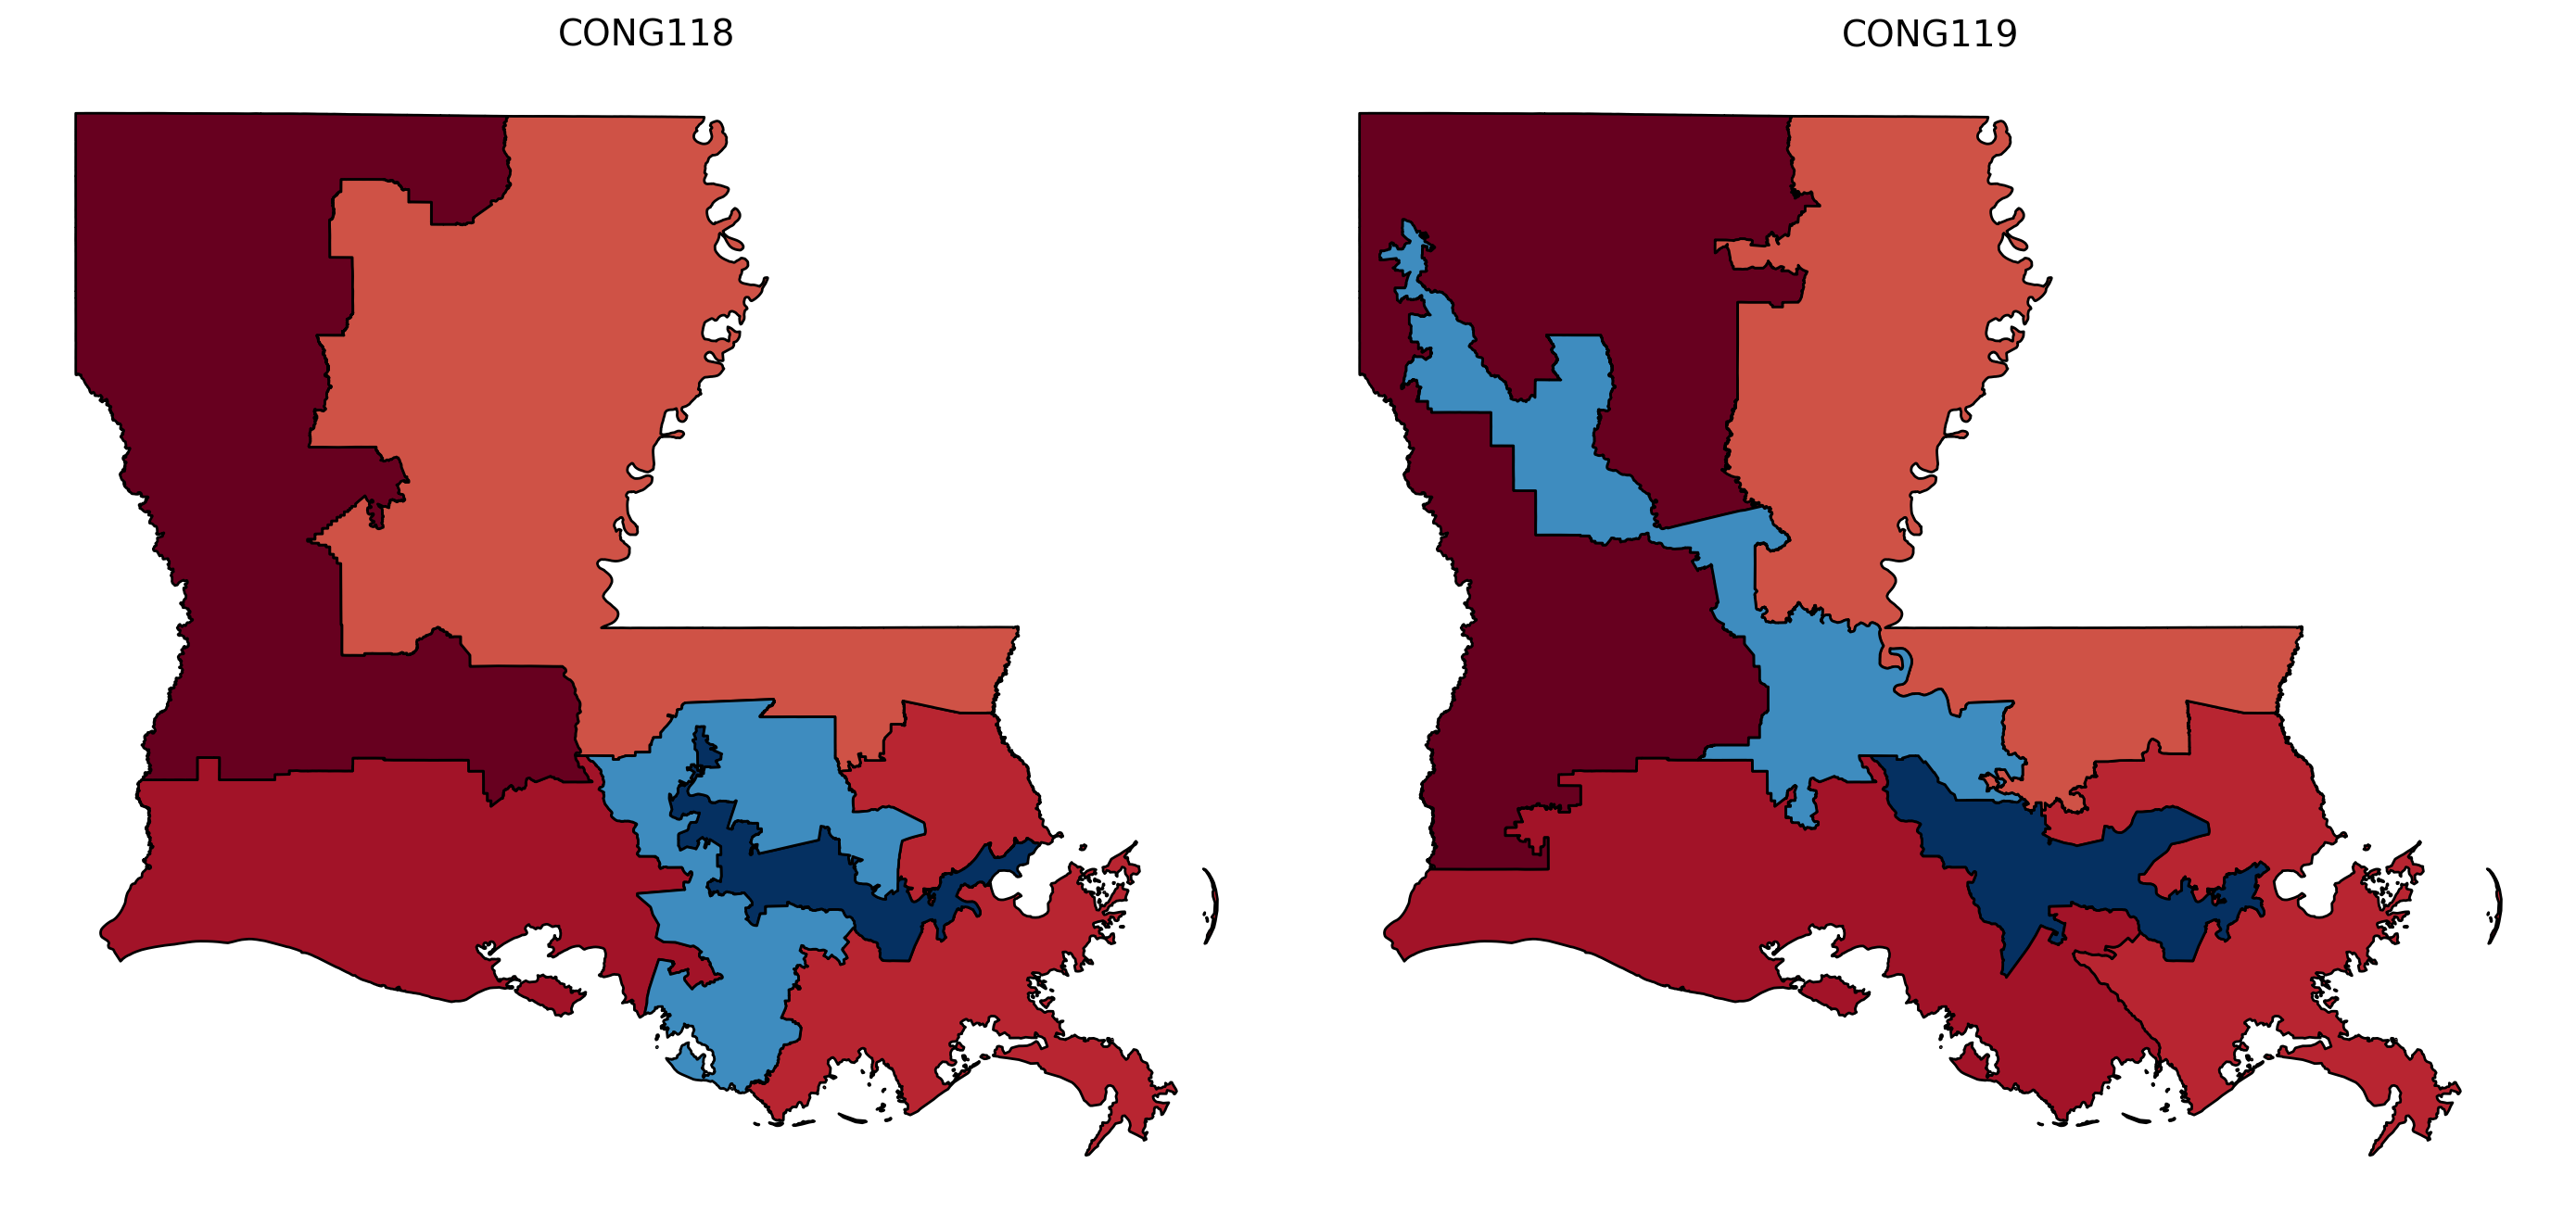

In [8]:
plot_comp("LA")

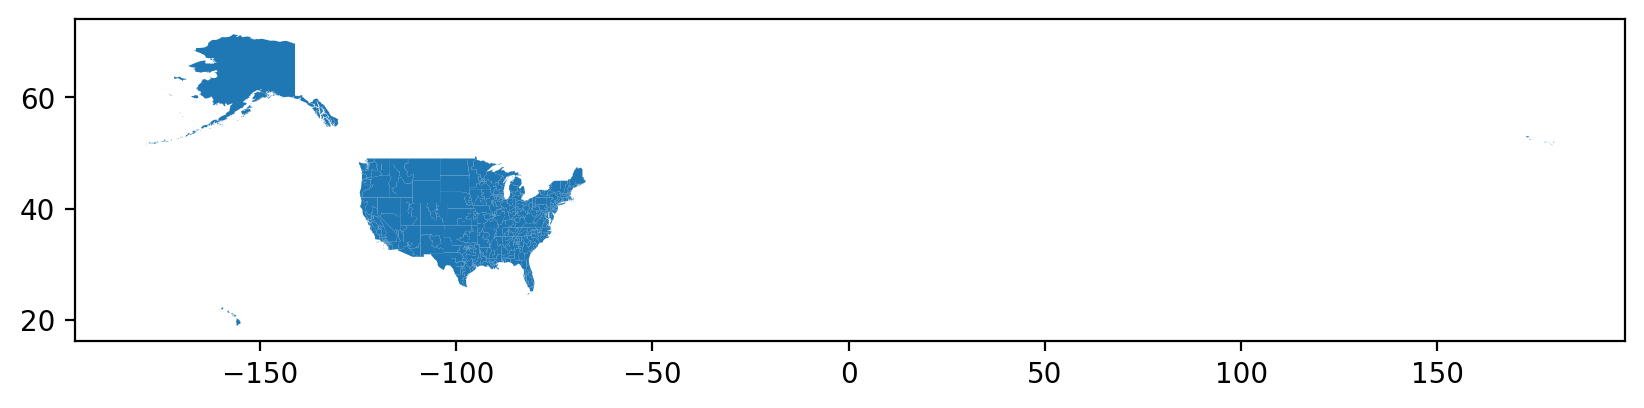

In [15]:
# plot shortcuts
# plot full image
dists.plot(figsize=(10, 10));

# plot fill image with coloring
dists.plot(
    column="BIDEN",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0.20,
    vmax = 0.80
);

# plot single state
IL.plot(figsize = (10, 10));

# plot single state with coloring
TX.plot(
    column="BIDEN",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0.20,
    vmax = 0.80
);

# plot single district
TX_1 = TX[TX["DISTRICT"] == "01"]
TX_1.plot(figsize = (10, 10));

In [16]:
#ME_1 = ME[ME["DISTRICT"] == "01"]
#ME_1.plot(figsize = (10, 10));

#ME_2 = ME[ME["DISTRICT"] == "02"]
#ME_2.plot(figsize = (10, 10));

ME_line = ME_1.intersection(ME_2, align = True)

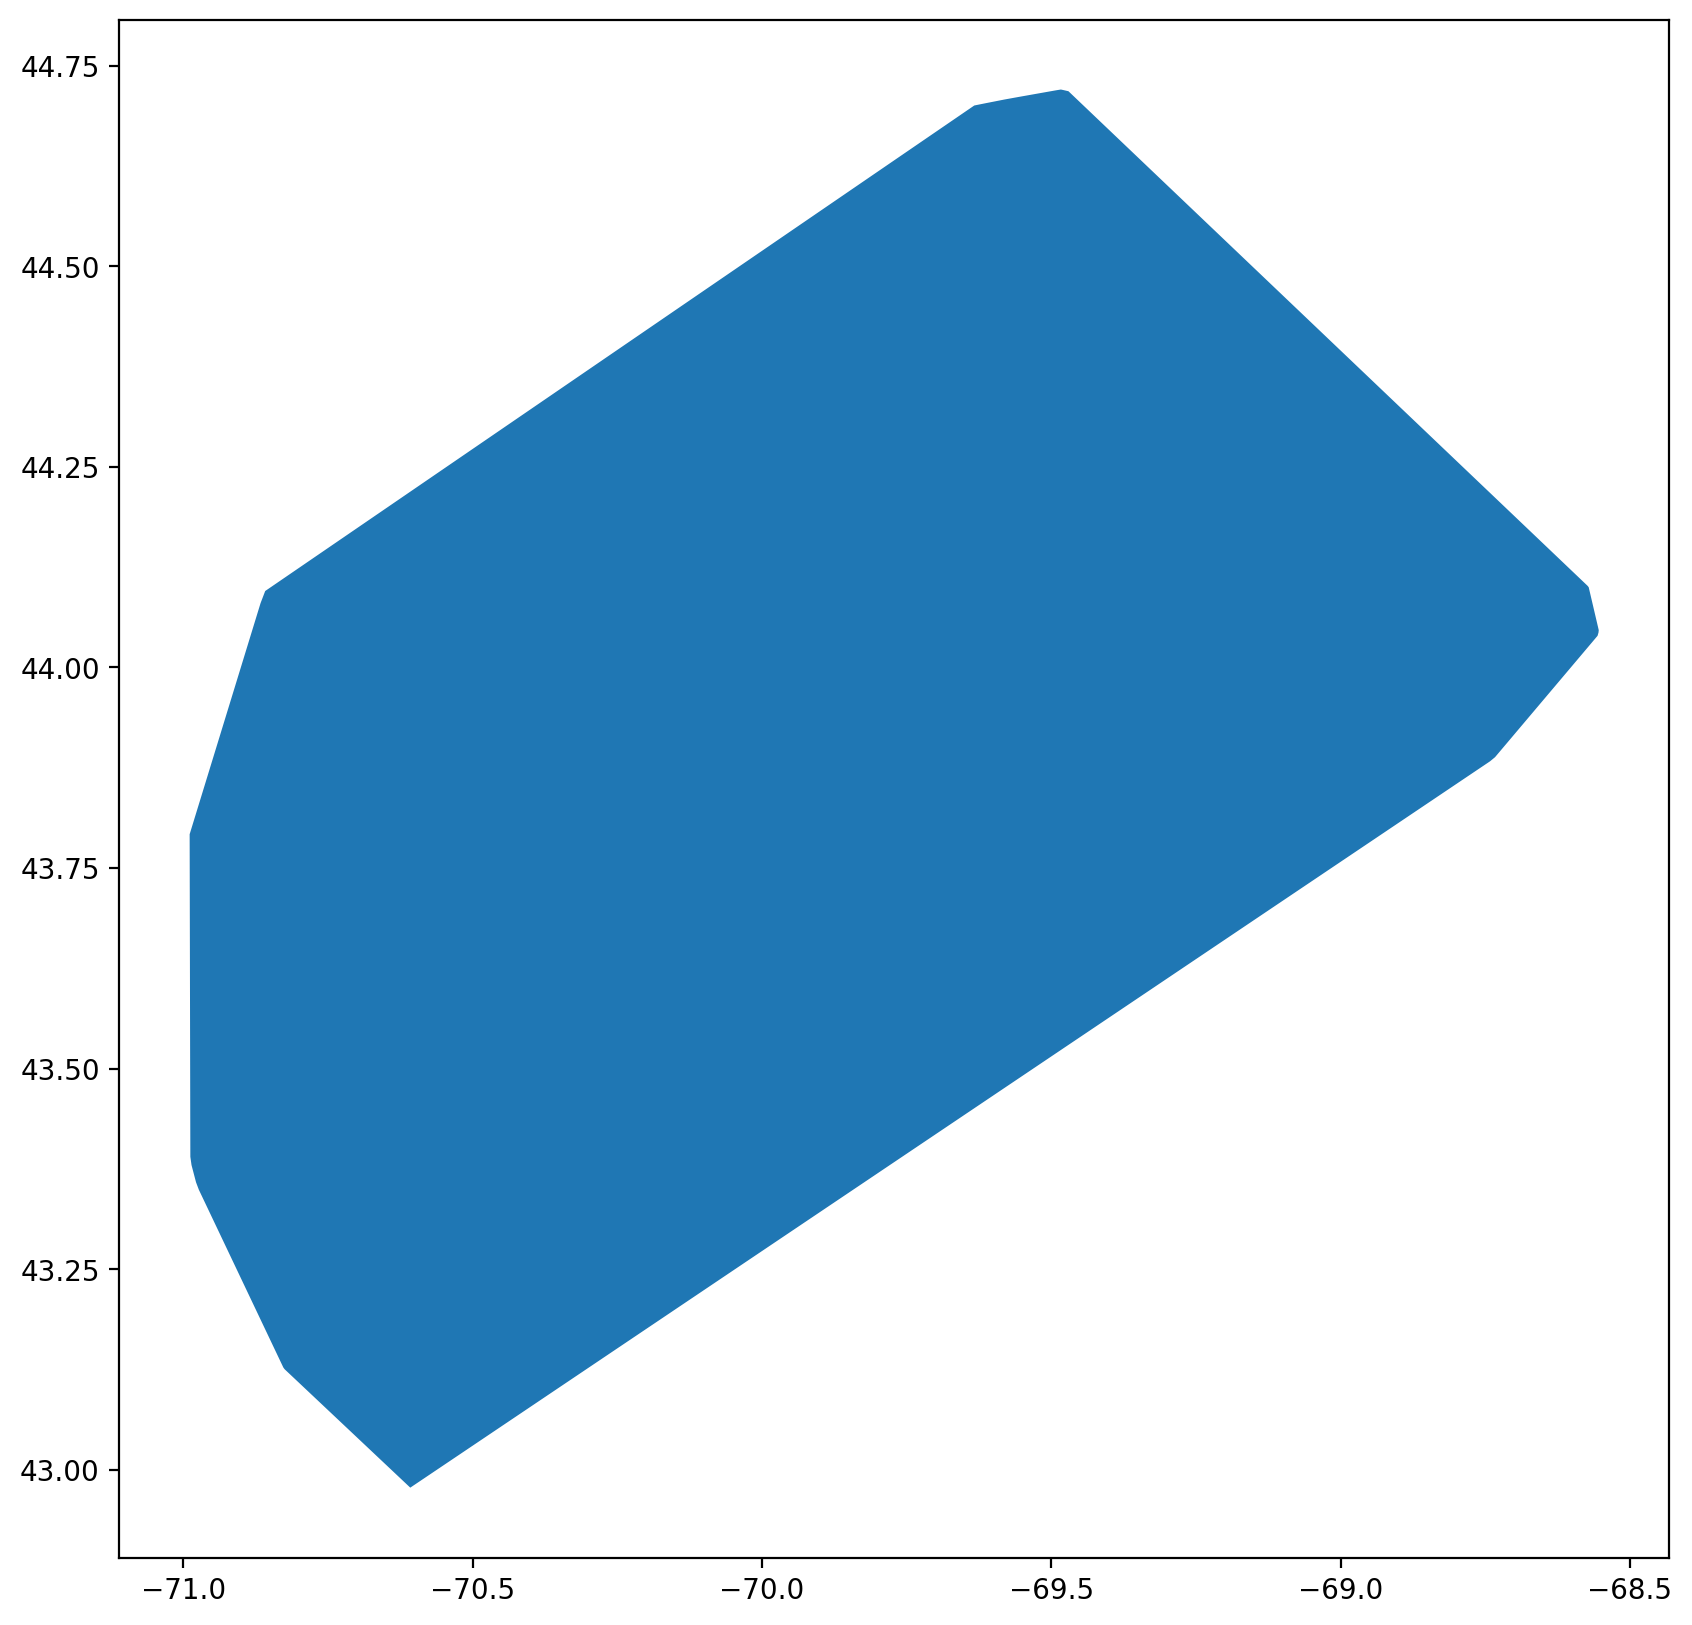

In [20]:
ME_1_hull = ME_1.convex_hull
ME_1_hull.plot(figsize = (10, 10));

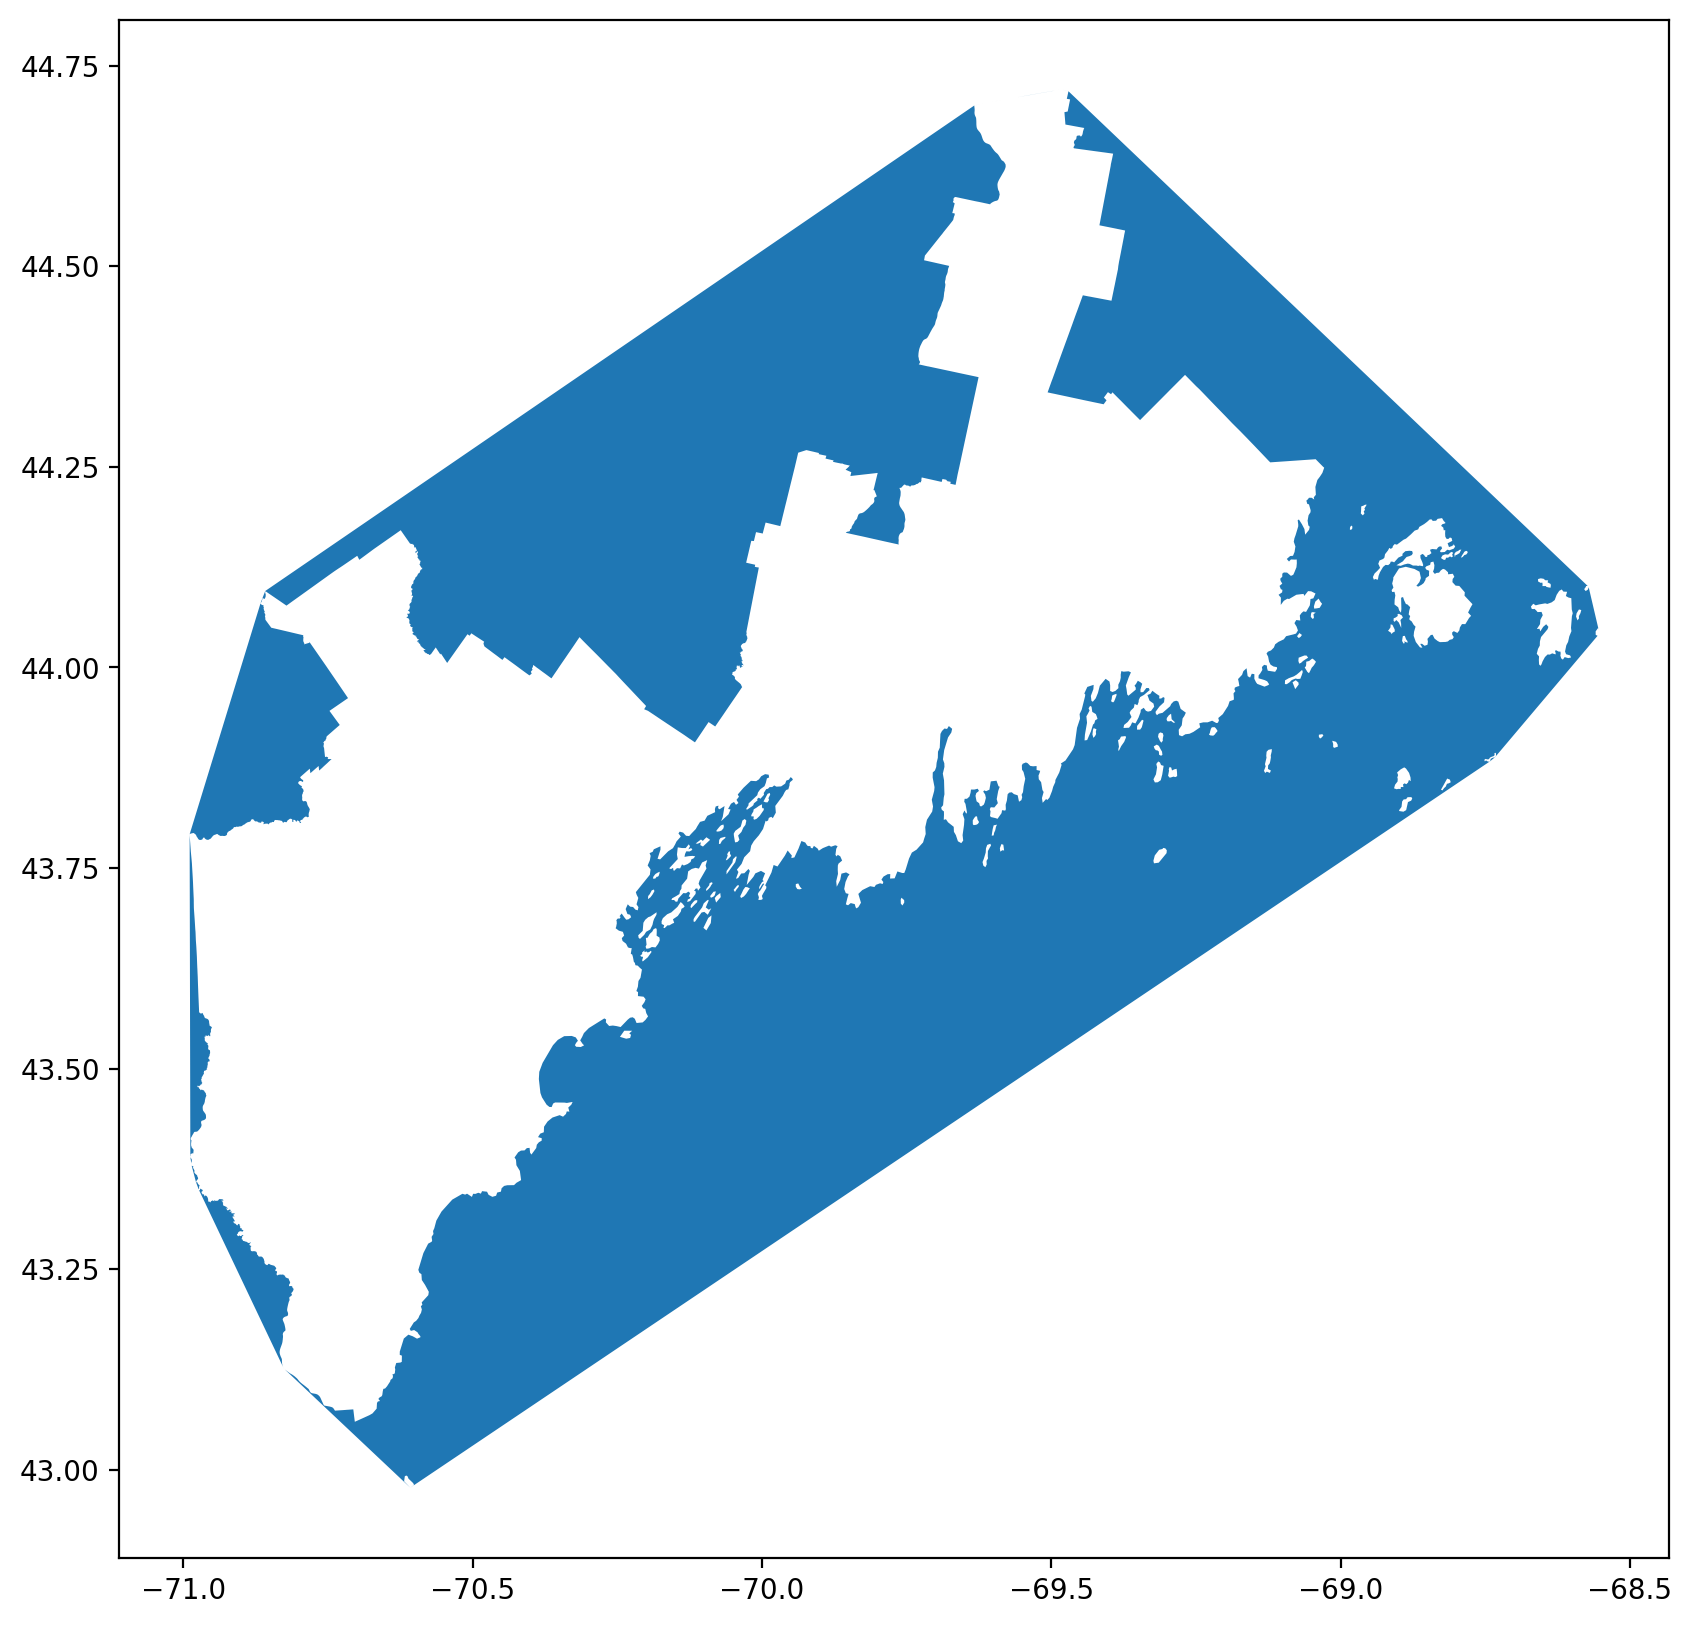

In [22]:
# idea: in order to account for / remove issue of weirdo boundaries, can just delete all of the stuff in this sd that doesnt overlap with the state
# can just use .difference
ME_1_sd = ME_1_hull.symmetric_difference(ME_1)
ME_1_sd.plot(figsize = (10, 10));

/tmp/ipykernel_2334820/2567168296.py:2: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  ME_1_ov = ME_1_sd.intersection(ME)


<Axes: >

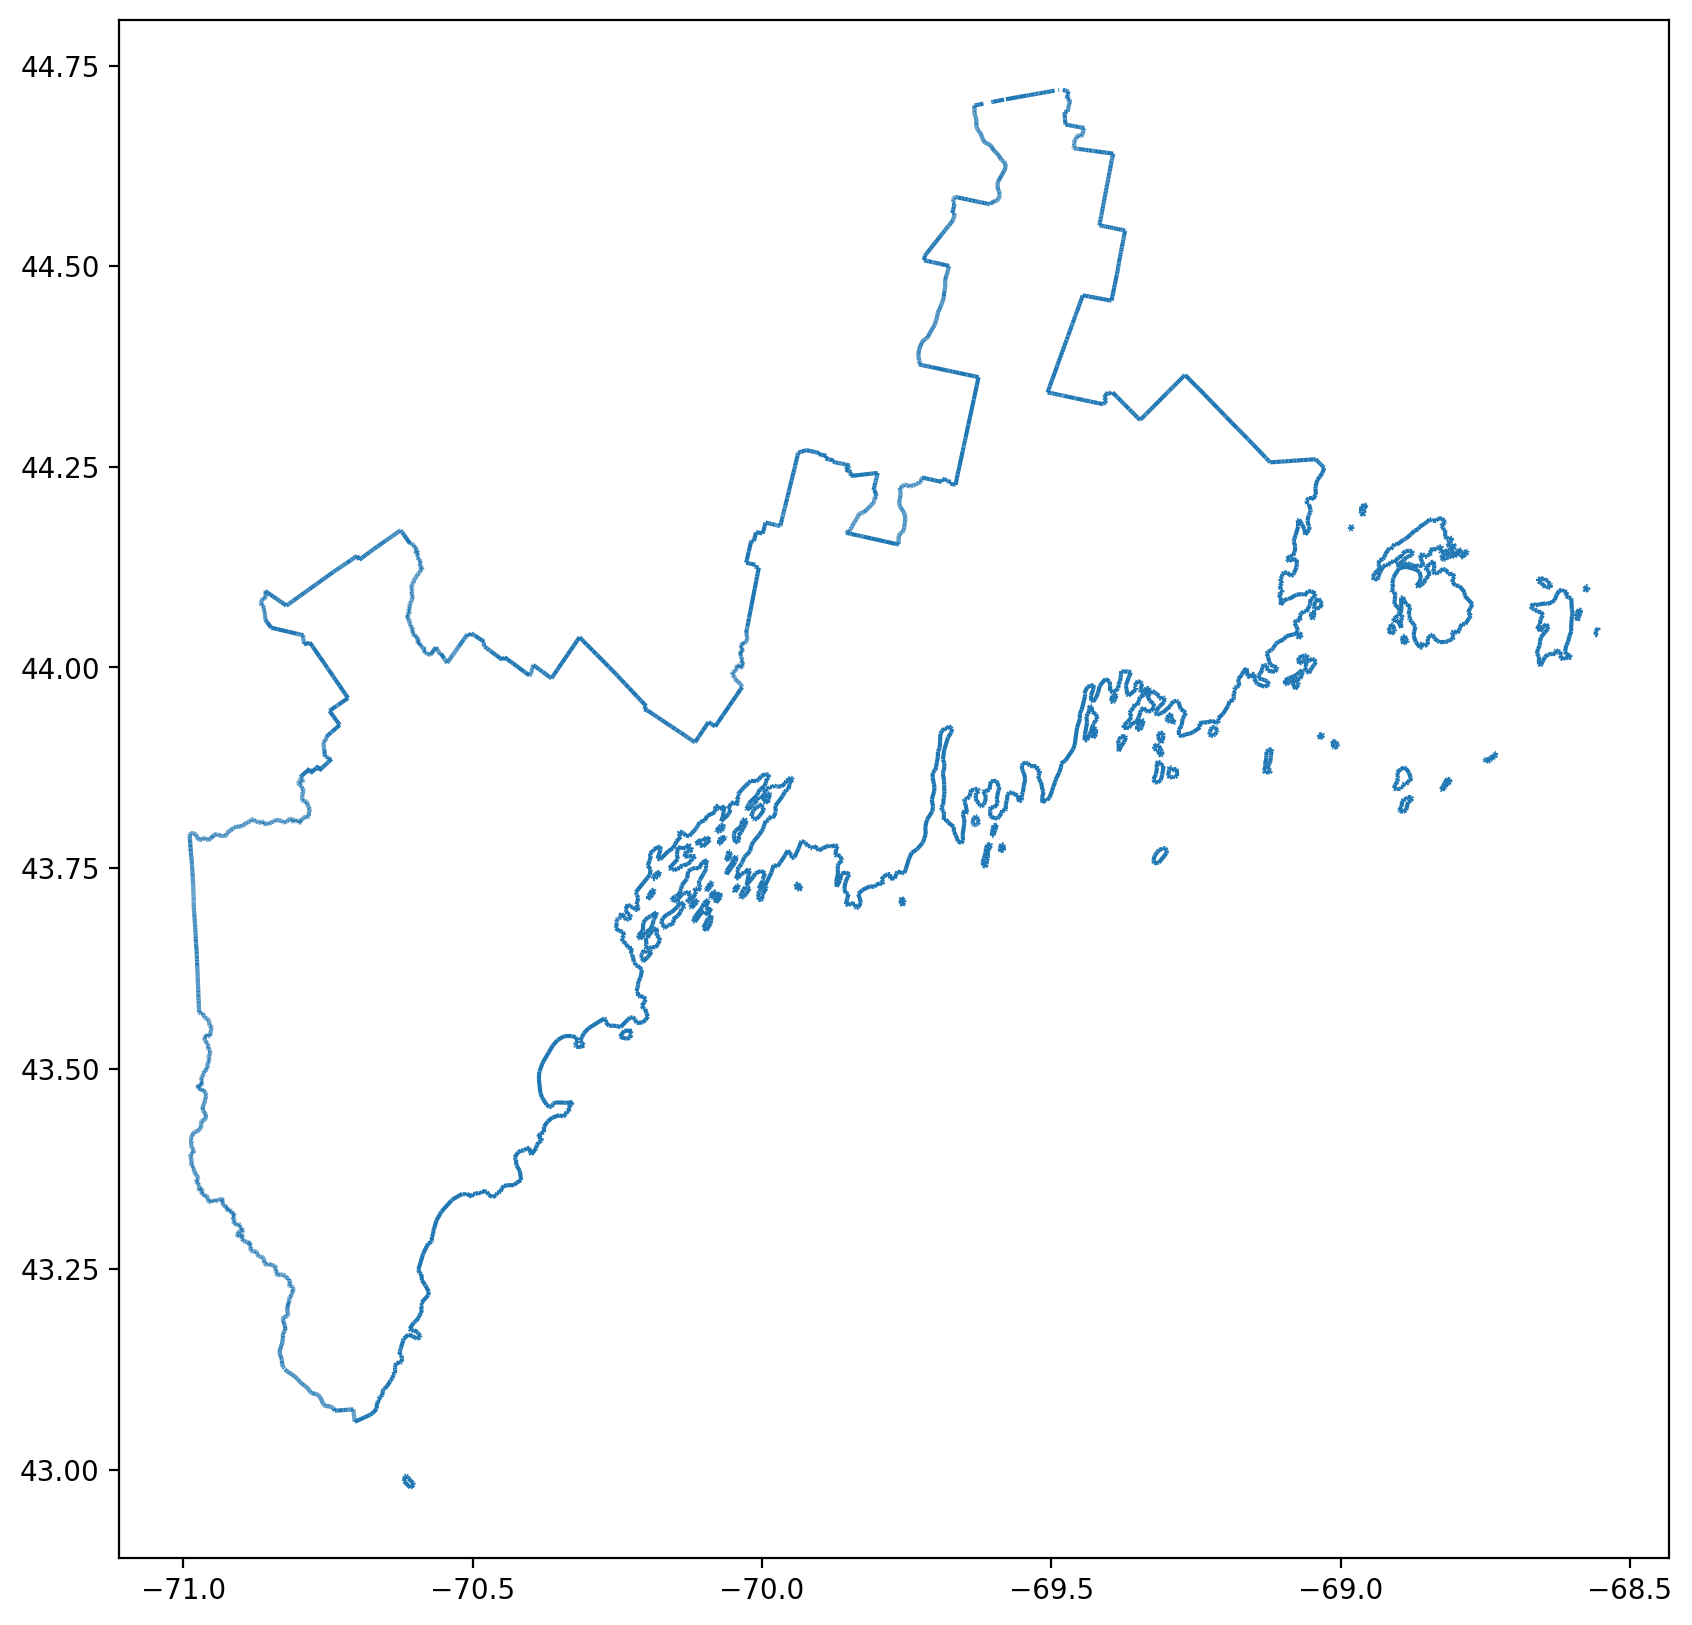

In [24]:
# remove area of the hull that doesnt overlap with the state
ME_1_ov = ME_1_sd.intersection(ME)
ME_1_ov.plot(figsize = (10,10))

In [29]:
ME_crs = ME_1.to_crs()
ME_crs.area

ValueError: Must pass either crs or epsg.

In [28]:
ME_2.area

/tmp/ipykernel_2334820/1995906653.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ME_2.area


220    8.703034
dtype: float64